In [21]:
import pandas as pd

dataset = pd.read_csv('dataset_preprocessed.csv')

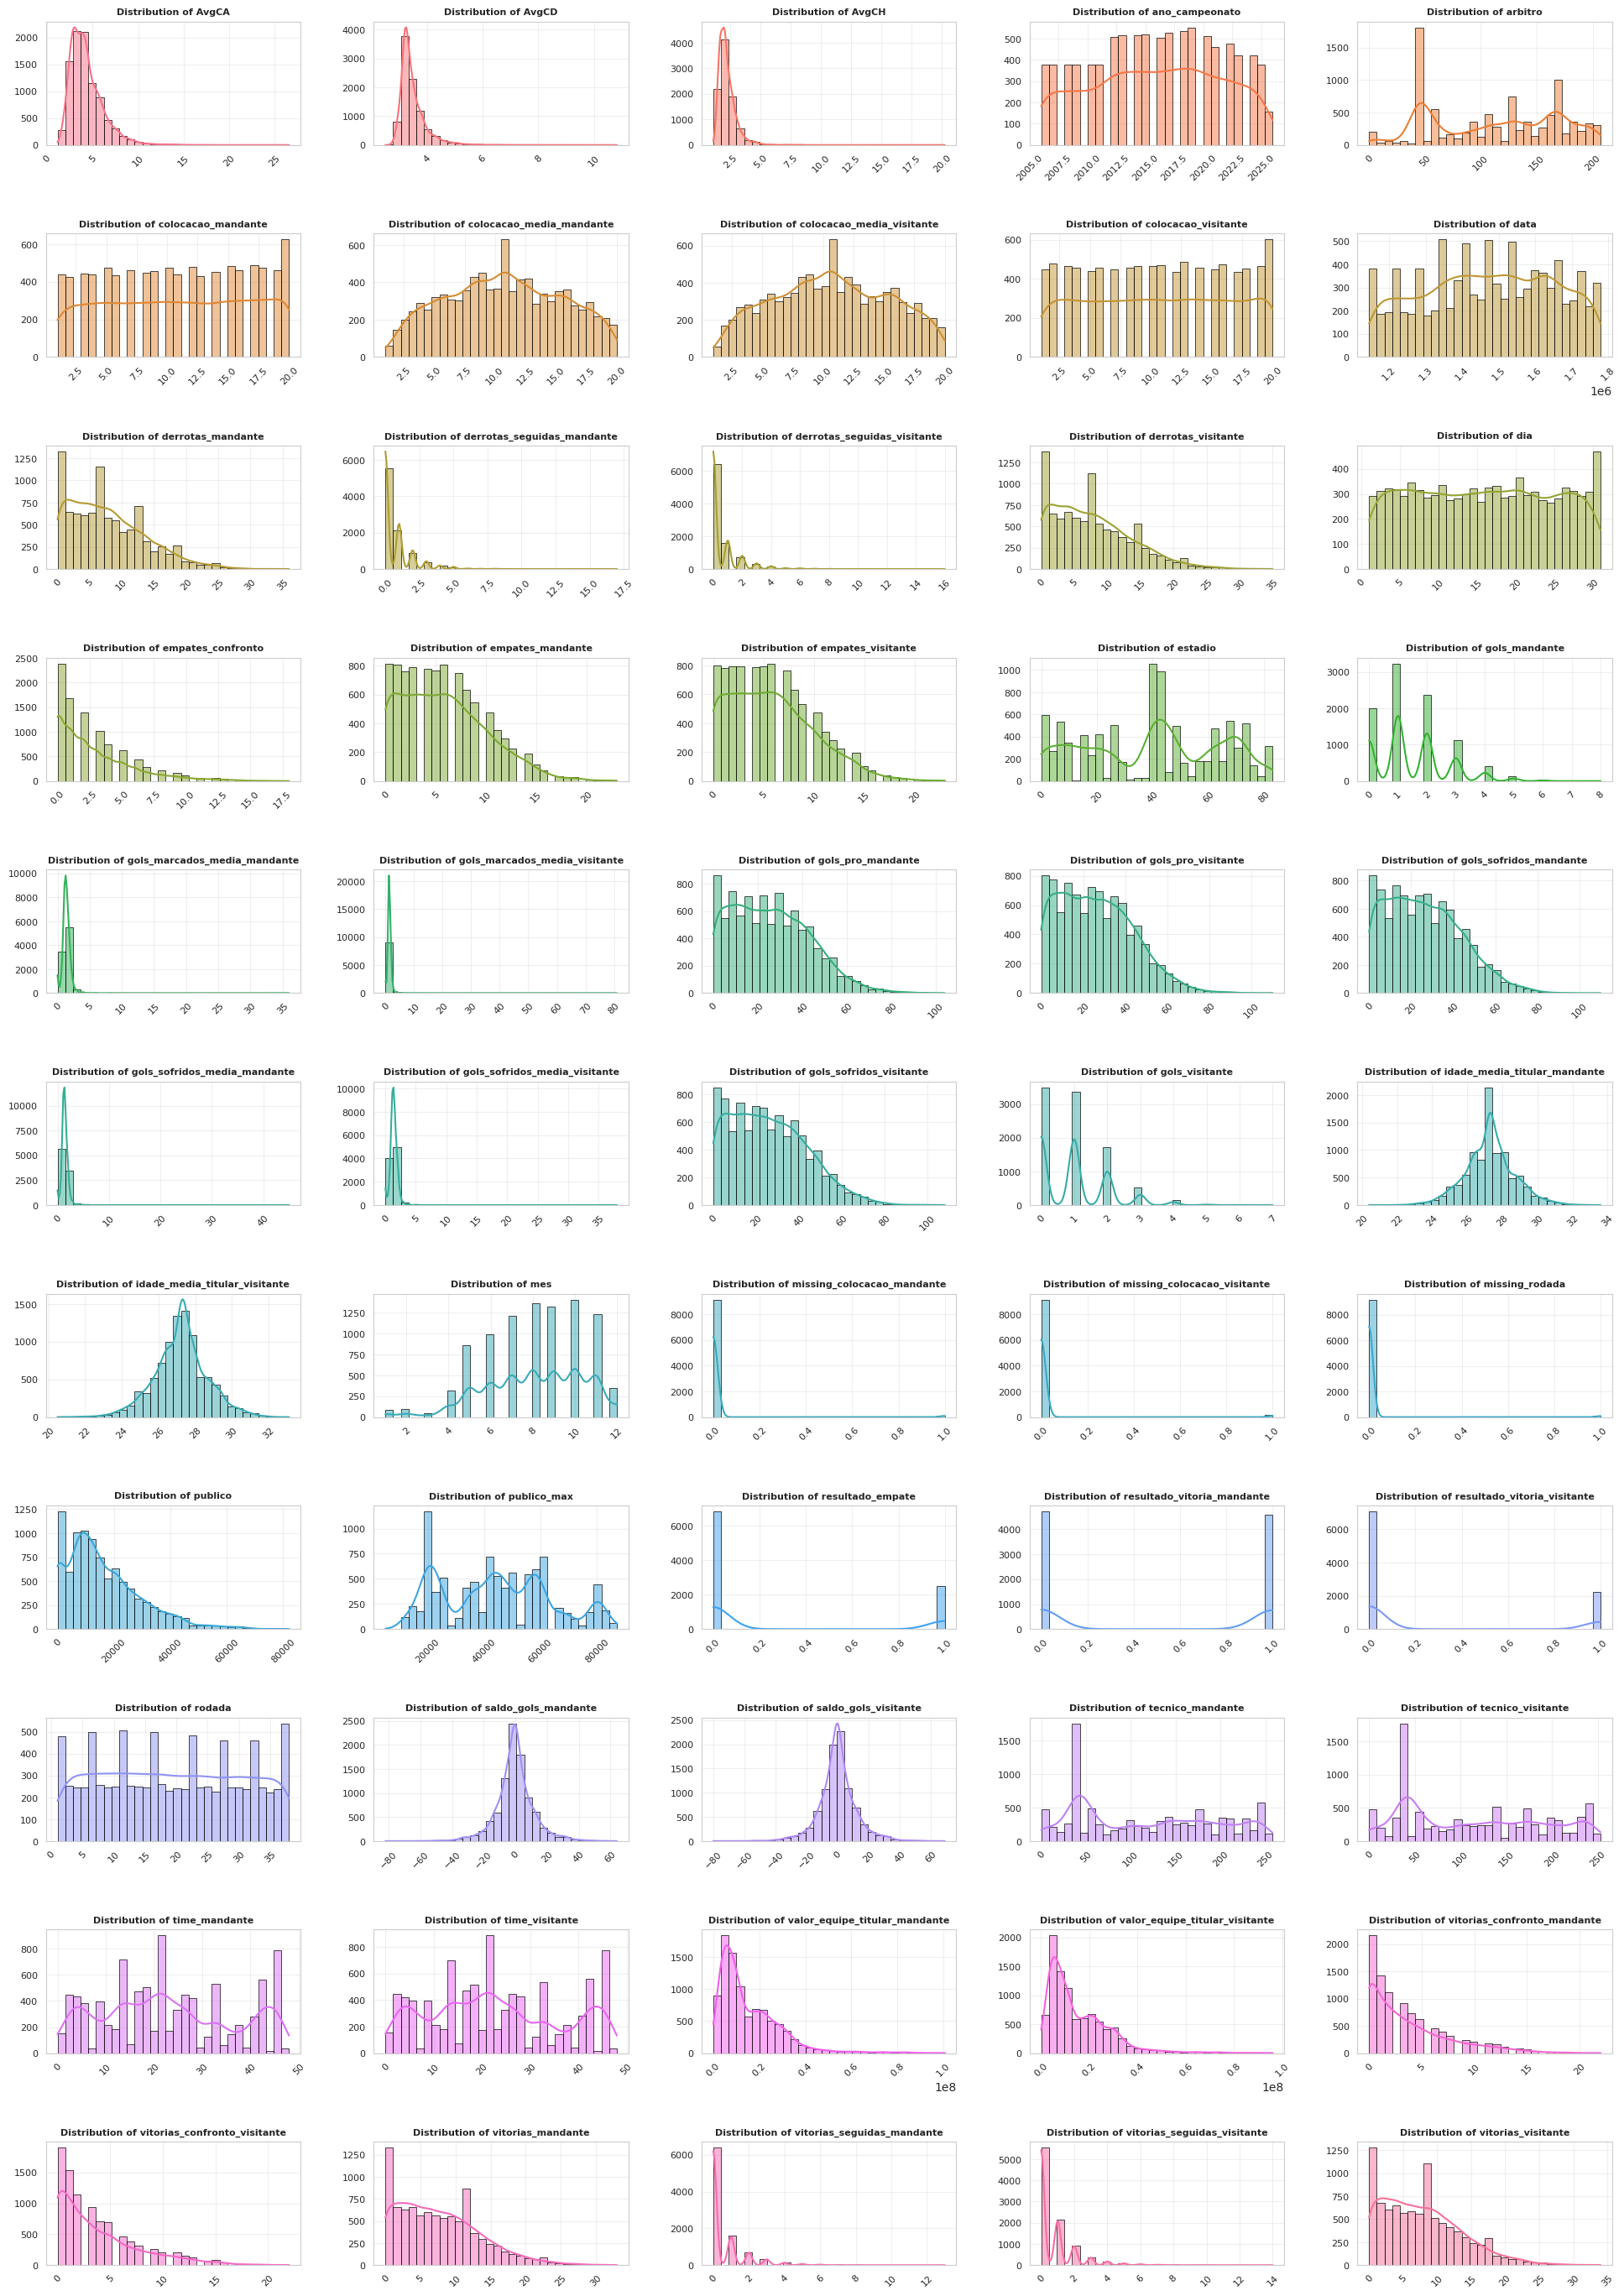

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_distributions(dataset):    
    # Set a visually appealing style for the plots
    sns.set_style('whitegrid')

    # Get the list of all columns in the dataset and sort them alphabetically
    columns = sorted(dataset.columns)
    num_columns = len(columns)

    # Define the grid size
    n_rows = 11
    n_cols = 5

    # Create the subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 28))

    # Flatten the axes array for easy iteration
    axes = axes.flatten()

    # Create a color palette
    palette = sns.color_palette("husl", num_columns)

    # Loop through the columns and plot a histogram for each
    for i, col in enumerate(columns):
        sns.histplot(dataset[col], kde=True, ax=axes[i], bins=30, color=palette[i], edgecolor='black', linewidth=0.5)
        axes[i].set_title(f'Distribution of {col}', fontsize=8, fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')
        axes[i].tick_params(axis='x', rotation=45, labelsize=8)
        axes[i].tick_params(axis='y', labelsize=8)
        axes[i].grid(alpha=0.3)

    # Hide any unused subplots
    for i in range(num_columns, len(axes)):
        axes[i].set_visible(False)

    # Adjust the layout to prevent titles and labels from overlapping
    plt.tight_layout(pad=3.0)

    # Display the plots
    plt.savefig('distributions.png', dpi=300)

plot_distributions(dataset)

In [23]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np

dist_normais_labels = ['saldo_gols_mandante', 'saldo_gols_visitante', 'idade_media_titular_mandante',
                       'idade_media_titular_visitante', 'colocacao_media_mandante', 'colocacao_media_visitante']

dist_cauda_longa_labels = ['publico', 'publico_max', 'valor_equipe_titular_mandante',
                           'valor_equipe_titular_visitante']

dist_poisson_labels = ['vitorias_mandante', 'vitorias_visitante', 'empates_mandante', 
                       'empates_visitante', 'derrotas_mandante', 'derrotas_visitante', 
                       'gols_pro_mandante', 'gols_pro_visitante', 'gols_sofridos_mandante',
                       'gols_sofridos_visitante', 'empates_confronto', 'vitorias_confronto_mandante', 
                       'vitorias_confronto_visitante',
                       'gols_marcados_media_mandante', 'gols_marcados_media_visitante',
                        'gols_sofridos_media_mandante', 'gols_sofridos_media_visitante',
                        'vitorias_seguidas_mandante', 'vitorias_seguidas_visitante',
                        'derrotas_seguidas_mandante', 'derrotas_seguidas_visitante',
                        'AvgCH', 'AvgCD', 'AvgCA']

#dist_categoricas_ciclicas_labels = ['data', 'rodada', 'time_mandante', 'time_visitante',
#                                    'colocacao_mandante', 'colocacao_visitante', 'dia', 'mes',
#                                    'estadio', 'arbitro', 'tecnico_mandante', 'tecnico_visitante']

dist_categoricas_ciclicas_labels = ['data', 'rodada', 'colocacao_mandante', 'colocacao_visitante', 'dia', 'mes']

# Initialize scalers
standard_scaler = StandardScaler()
min_max_scaler = MinMaxScaler()

# Apply StandardScaler to normally distributed columns
for col in dist_normais_labels:
    if col in dataset.columns:
        dataset[col] = standard_scaler.fit_transform(dataset[[col]])

# Apply log transformation and then MinMaxScaler to long-tail distributed columns
for col in dist_cauda_longa_labels:
    if col in dataset.columns:
        dataset[col] = np.log1p(dataset[col])
        dataset[col] = min_max_scaler.fit_transform(dataset[[col]])

# Combine Poisson and cyclical categorical labels
dist_minmax_labels = dist_poisson_labels + dist_categoricas_ciclicas_labels

# Apply MinMaxScaler to the combined list of columns
for col in dist_minmax_labels:
    if col in dataset.columns:
        dataset[col] = min_max_scaler.fit_transform(dataset[[col]])

print("Scaling and transformations applied successfully.")
dataset.describe()

Scaling and transformations applied successfully.


,ano_campeonato,data,rodada,estadio,arbitro,publico,publico_max,time_mandante,time_visitante,tecnico_mandante,...,gols_marcados_media_visitante,vitorias_confronto_mandante,vitorias_confronto_visitante,empates_confronto,vitorias_seguidas_mandante,vitorias_seguidas_visitante,colocacao_media_mandante,colocacao_media_visitante,derrotas_seguidas_mandante,derrotas_seguidas_visitante
count,9294.000000,9294.000000,9294.000000,9294.000000,9294.000000,9294.000000,9294.000000,9294.000000,9294.000000,9294.000000,...,9294.000000,9294.000000,9294.000000,9294.000000,9294.000000,9294.000000,9.294000e+03,9.294000e+03,9294.000000,9294.000000
mean,2015.954056,0.513374,0.497307,39.701743,113.187218,0.754200,0.726127,22.789864,22.789111,116.855283,...,0.017498,0.166799,0.171988,0.152458,0.043792,0.051546,-1.498455e-16,-3.210974e-17,0.042659,0.036771
std,5.576516,0.277235,0.297508,24.059266,56.321226,0.269183,0.172447,13.515890,13.500309,76.751051,...,0.013730,0.176226,0.177031,0.162810,0.085396,0.084557,1.000054e+00,1.000054e+00,0.070815,0.073703
min,2006.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.053995e+00,-2.045322e+00,0.000000,0.000000
25%,2012.000000,0.306290,0.243243,19.000000,57.000000,0.783368,0.557316,13.000000,13.000000,42.000000,...,0.013228,0.045455,0.045455,0.000000,0.000000,0.000000,-7.865906e-01,-7.783302e-01,0.000000,0.000000
50%,2016.000000,0.518195,0.486486,42.000000,118.000000,0.838008,0.757825,22.000000,22.000000,109.000000,...,0.016461,0.090909,0.136364,0.111111,0.000000,0.000000,1.266225e-02,-8.669440e-03,0.000000,0.000000
75%,2020.000000,0.740221,0.756757,62.000000,166.000000,0.887606,0.856823,33.000000,33.000000,182.000000,...,0.020833,0.272727,0.272727,0.222222,0.076923,0.071429,7.976647e-01,8.149042e-01,0.058824,0.062500
max,2026.000000,1.000000,1.000000,83.000000,207.000000,1.000000,1.000000,48.000000,48.000000,258.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.959452e+00,1.966820e+00,1.000000,1.000000


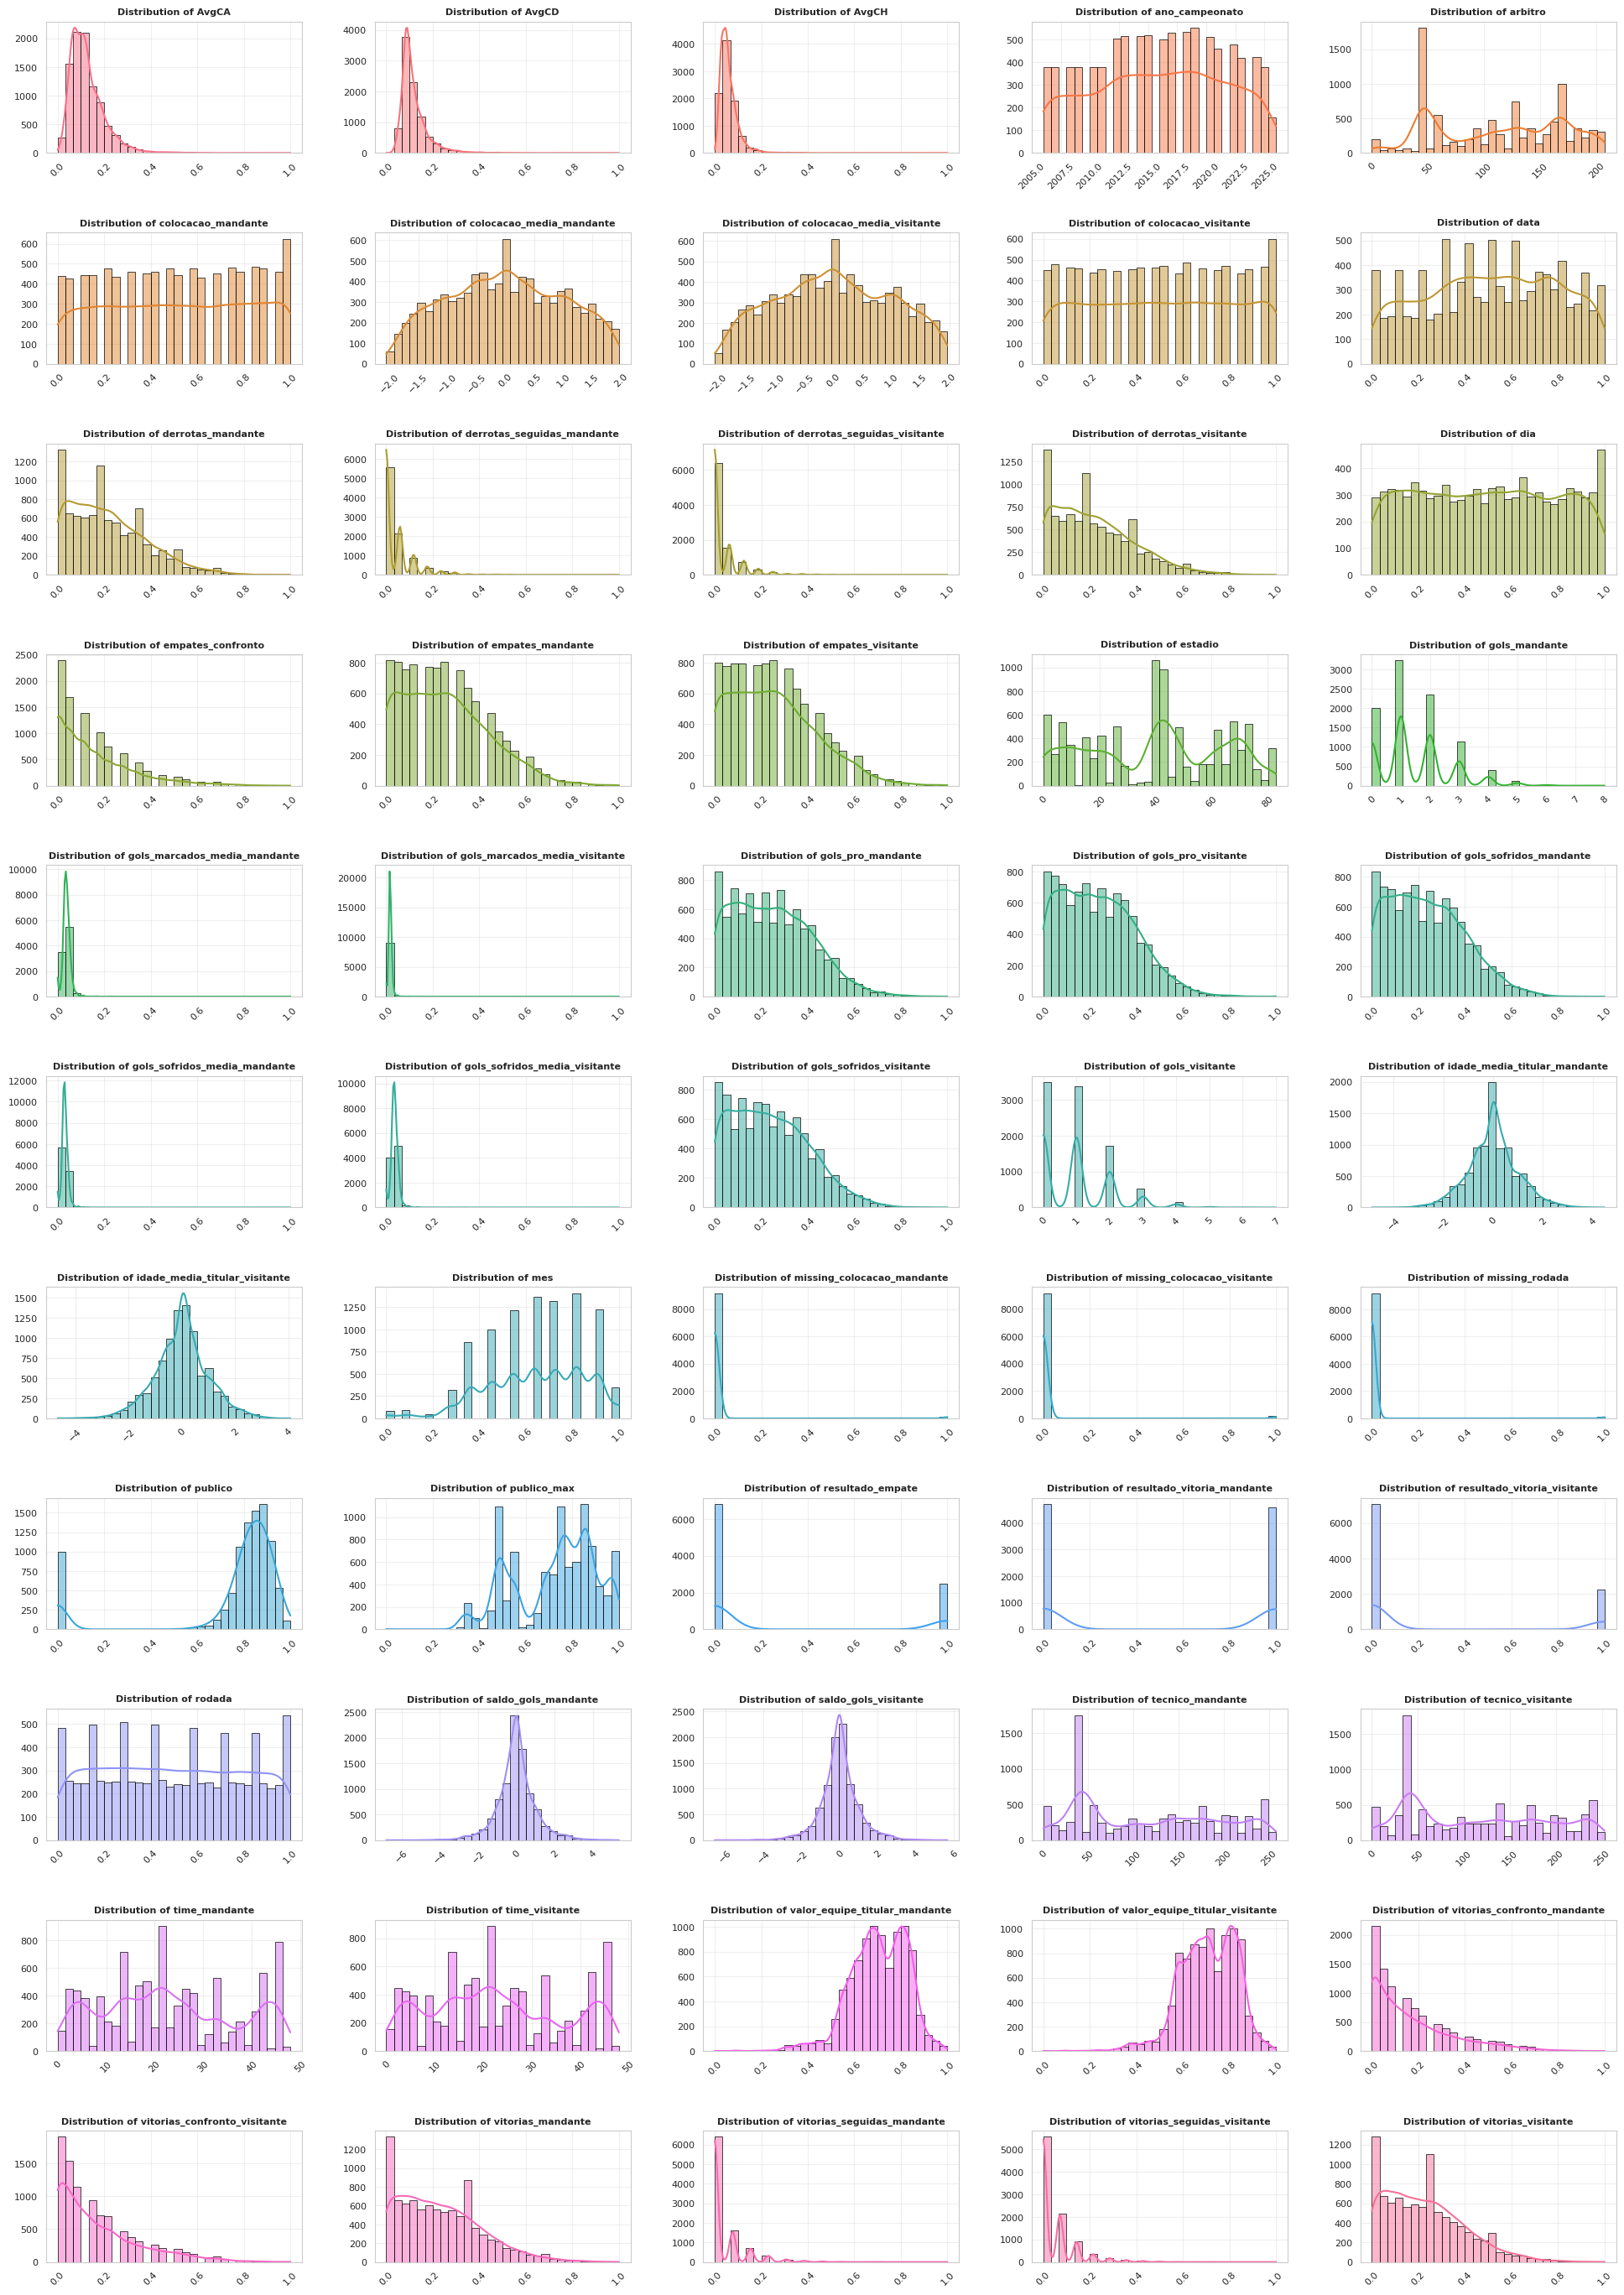

In [24]:
plot_distributions(dataset)

In [25]:
dataset.to_csv('dataset_scaled.csv', index=False)

dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 9294 entries, 0 to 9293
Data columns (total 55 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ano_campeonato                  9294 non-null   int64  
 1   data                            9294 non-null   float64
 2   rodada                          9294 non-null   float64
 3   estadio                         9294 non-null   int64  
 4   arbitro                         9294 non-null   int64  
 5   publico                         9294 non-null   float64
 6   publico_max                     9294 non-null   float64
 7   time_mandante                   9294 non-null   int64  
 8   time_visitante                  9294 non-null   int64  
 9   tecnico_mandante                9294 non-null   int64  
 10  tecnico_visitante               9294 non-null   int64  
 11  colocacao_mandante              9294 non-null   float64
 12  colocacao_visitante             9294 non-null